In [38]:
## IMPORTING
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
X = df.drop(columns="Class")
y = df["Class"]


In [4]:
# Splitting the Training and Testing data
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,stratify=y,random_state=42)

In [5]:

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

0.9995962220427653
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
sc = SMOTE(random_state=42)
X_train_res,y_train_res = sc.fit_resample(X_train,y_train)

In [7]:
modell = RandomForestClassifier()
modell.fit(X_train_res, y_train_res)
yy_pred = modell.predict(X_test)

print(accuracy_score(y_test,yy_pred))

print(classification_report(y_test,yy_pred))

0.9994382219725431
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# Feature Selection

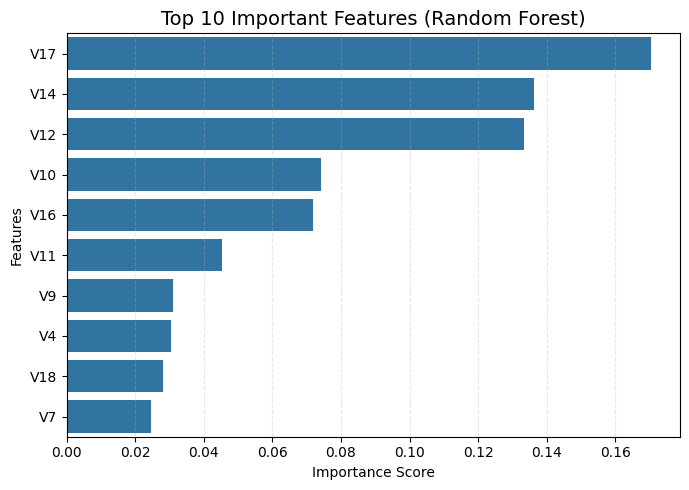

In [ ]:
importance = model.feature_importances_
features = X.columns

fem = pd.Series(importance, index=features).sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(7,5))

sns.barplot(
    x=fem.values,
    y=fem.index
)

plt.title("Top 10 Important Features (Random Forest)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\91706\AppData\Local\Temp\ipykernel_15716\2672962789.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


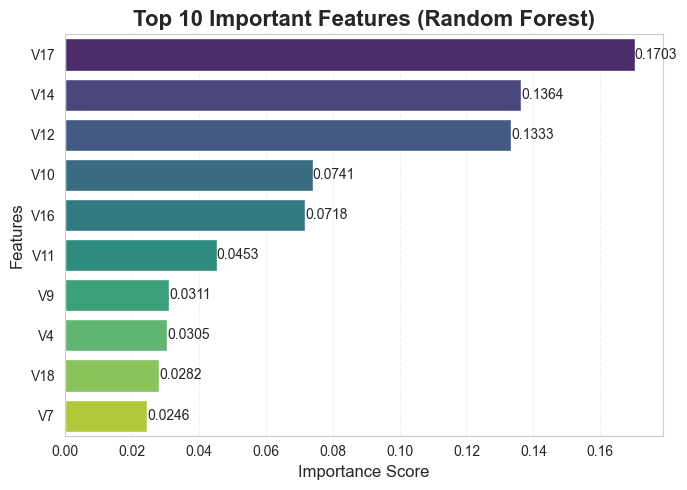

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
importance = model.feature_importances_
features = X.columns

fem = pd.Series(importance, index=features).sort_values(ascending=False).head(10)

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(7,5))

# Color palette (gradient look)
colors = sns.color_palette("viridis", len(fem))

sns.barplot(
    x=fem.values,
    y=fem.index,
    palette=colors
)

# Labels
plt.title("Top 10 Important Features (Random Forest)", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Add values on bars
for i, v in enumerate(fem.values):
    plt.text(v, i, f"{v:.4f}", va='center', fontsize=10)

# Clean layout
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()